# FlyRank Search Intelligence Capstone

## Lane

Refresh / Content Opportunity Scoring

## Research Question

Can safe search-performance signals be used to rank pages that deserve review for decline, recovery, or improvement?

## Goal

The goal of this project is to build and validate a repeatable machine-learning workflow that ranks content pages for human review. The workflow uses safe search-performance signals to identify pages that may need attention and provides reason codes to explain why a page was prioritized.

The model is designed as a decision-support tool. It does not prove causation, predict Google's algorithm, or automatically decide what changes should be made to a page.


In [1]:
import os
import pandas as pd
import numpy as np

# Find the FlyRank repository
repo_path = "flyrank-ml-internship"

if not os.path.exists(repo_path):
    !git clone https://github.com/Duchalsoham12/flyrank-ml-internship.git

# Find the dataset
csv_path = None

for root, dirs, files in os.walk(repo_path):
    for file in files:
        if file == "content_refresh_anonymized.csv":
            csv_path = os.path.join(root, file)
            break

if csv_path is None:
    raise FileNotFoundError(
        "content_refresh_anonymized.csv not found."
    )

# Load dataset
df = pd.read_csv(csv_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (30000, 44)


In [2]:
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 3. Data Understanding

The dataset contains anonymized content-performance records. Before modeling, the data is inspected to understand its size, available variables, and the distribution of the decline label.

The target label identifies records where the observed trend direction is `down`. This label is used only as the outcome for model training and evaluation.


In [3]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 30000
Number of columns: 44

Column names:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


In [4]:
df["is_declining_label"] = (
    df["trend_direction"]
    .astype(str)
    .str.lower()
    .eq("down")
    .astype(int)
)

print("Target label created successfully.")

Target label created successfully.


In [5]:
df["is_declining_label"] = (
    df["trend_direction"]
    .astype(str)
    .str.lower()
    .eq("down")
    .astype(int)
)

print("Target label created successfully.")

Target label created successfully.


In [6]:
print("Declining label distribution:")
print(df["is_declining_label"].value_counts())

print("\nDeclining label proportion:")
print(df["is_declining_label"].value_counts(normalize=True).round(3))

Declining label distribution:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64

Declining label proportion:
is_declining_label
1    0.542
0    0.458
Name: proportion, dtype: float64


In [7]:
print("Number of clients:", df["client_id"].nunique())

Number of clients: 32


## 4. Leakage Check & Feature Selection

To reduce target leakage, fields that directly define the decline label or contain client identifiers are excluded from the model.

The model uses only the remaining safe content and search-performance features. Client identifiers are retained separately for grouped validation but are not used as predictive features.


In [8]:
# Columns excluded from model features
excluded = {
    "content_id",
    "client_id",
    "trend_direction",
    "trend_pct",
    "is_declining_label"
}

# Create model feature list
features = [
    c for c in df.columns
    if c not in excluded
]

print("Excluded columns:")
for col in sorted(excluded):
    print("-", col)

print("\nNumber of model features:", len(features))

print("\nModel features:")
print(features)

Excluded columns:
- client_id
- content_id
- is_declining_label
- trend_direction
- trend_pct

Number of model features: 40

Model features:
['search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier']


In [9]:
leakage_check = [
    col for col in excluded
    if col in features
]

if len(leakage_check) == 0:
    print("✓ Leakage check passed.")
    print("No excluded columns are being used as model features.")
else:
    print("⚠ Leakage detected:", leakage_check)

✓ Leakage check passed.
No excluded columns are being used as model features.


✓ Leakage check passed.
No excluded columns are being used as model features.

In [10]:
missing = df[features].isnull().sum()

print("Features with missing values:")
display(
    missing[missing > 0]
    .sort_values(ascending=False)
    .head(15)
)

Features with missing values:


,0
provider_used,21438
word_count_tier,7699
word_count,7699
char_count,7699
char_count_tier,7699
model_used,5733
competition_level,2610
search_volume,2468
cpc,2468
competition,2468


## 5. Validation Design

A client-grouped 80/20 split is used for validation. Client identifiers are used only to define the groups and are not included as model features.

This prevents records from the same client from appearing in both training and test sets, reducing the risk of overly optimistic evaluation caused by client-level overlap.


In [11]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        df,
        y=df["is_declining_label"],
        groups=df["client_id"]
    )
)

train = df.iloc[train_idx].copy()
test = df.iloc[test_idx].copy()

print("Training rows:", len(train))
print("Testing rows:", len(test))

print("Training clients:", train["client_id"].nunique())
print("Testing clients:", test["client_id"].nunique())

Training rows: 23837
Testing rows: 6163
Training clients: 25
Testing clients: 7


In [12]:
train_clients = set(train["client_id"])
test_clients = set(test["client_id"])

overlap = train_clients & test_clients

print("Client overlap:", len(overlap))

if len(overlap) == 0:
    print("✓ Grouped split passed.")
    print("No client appears in both training and testing sets.")
else:
    print("⚠ Client overlap detected!")
    print(overlap)

Client overlap: 0
✓ Grouped split passed.
No client appears in both training and testing sets.


In [13]:
X_train = train[features]
y_train = train["is_declining_label"]

X_test = test[features]
y_test = test["is_declining_label"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (23837, 40)
y_train: (23837,)
X_test: (6163, 40)
y_test: (6163,)


## 6. Baseline

A simple transparent baseline is used as a reference model. It ranks test records using the available `trend_pct` signal, with more negative values receiving higher priority.

The baseline is intentionally simple and interpretable. The Random Forest model will later be compared against this baseline on the same held-out test set.


In [14]:
# Create a simple baseline ranking
baseline_test = test[
    ["content_id", "trend_pct", "is_declining_label"]
].copy()

# More negative trend = higher decline priority
baseline_test["baseline_score"] = -baseline_test["trend_pct"]

# Rank from highest priority to lowest
baseline_test = baseline_test.sort_values(
    "baseline_score",
    ascending=False
).reset_index(drop=True)

# Precision@50
top_n = min(50, len(baseline_test))

baseline_p50 = (
    baseline_test
    .iloc[:top_n]["is_declining_label"]
    .mean()
)

print("Baseline Precision@50:", round(baseline_p50, 3))

Baseline Precision@50: 1.0


In [15]:
display(
    baseline_test[
        [
            "content_id",
            "trend_pct",
            "baseline_score",
            "is_declining_label"
        ]
    ].head(10)
)

,content_id,trend_pct,baseline_score,is_declining_label
0,content_9bb9a0584cae,-100.0,100.0,1
1,content_94d56e0730af,-100.0,100.0,1
2,content_a6cb5ab8b859,-100.0,100.0,1
3,content_f3464a853034,-100.0,100.0,1
4,content_414627c66f75,-100.0,100.0,1
5,content_c00a56f387ba,-100.0,100.0,1
6,content_9bb78e058f1d,-100.0,100.0,1
7,content_00636cafb5a2,-100.0,100.0,1
8,content_27e6ada72037,-100.0,100.0,1
9,content_a235b8bfea91,-100.0,100.0,1


## 7. Random Forest Model

A Random Forest classifier is trained using the selected non-leaking features. Numeric missing values are replaced using the median, while categorical missing values are replaced using the most frequent category and then one-hot encoded.

The model is trained only on the training clients and evaluated later on the held-out test clients.


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# Identify feature types
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 29
Categorical features: 11


In [17]:
preprocessor = ColumnTransformer([
    (
        "num",
        SimpleImputer(strategy="median"),
        numeric_features
    ),
    (
        "cat",
        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "onehot",
                OneHotEncoder(handle_unknown="ignore")
            )
        ]),
        categorical_features
    )
])

In [18]:
model = Pipeline([
    (
        "prep",
        preprocessor
    ),
    (
        "rf",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        )
    )
])

In [19]:
model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [20]:
pred_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated:", len(pred_prob))
print("Minimum score:", round(pred_prob.min(), 3))
print("Maximum score:", round(pred_prob.max(), 3))

Predictions generated: 6163
Minimum score: 0.003
Maximum score: 0.977


## 8. Model Evaluation

The Random Forest is evaluated on the same held-out test clients used for the baseline. Precision@50 is used as the main ranking metric because the practical goal is to identify a small number of high-priority pages for human review.

Precision@50 represents the proportion of the top 50 ranked pages that are actually labeled as declining.


In [21]:
# Rank test records by model probability
top_indices = np.argsort(pred_prob)[::-1][:50]

model_p50 = y_test.iloc[top_indices].mean()

print("Random Forest Precision@50:", round(model_p50, 3))

Random Forest Precision@50: 1.0


In [22]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Random Forest"
    ],
    "Precision@50": [
        baseline_p50,
        model_p50
    ]
})

display(comparison)

,Model,Precision@50
0,Baseline,1.0
1,Random Forest,1.0


In [23]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Random Forest"
    ],
    "Precision@50": [
        baseline_p50,
        model_p50
    ]
})

display(comparison)

,Model,Precision@50
0,Baseline,1.0
1,Random Forest,1.0


In [24]:
improvement = model_p50 - baseline_p50

print(
    "Absolute improvement:",
    round(improvement, 3)
)

Absolute improvement: 0.0


In [25]:
improvement = model_p50 - baseline_p50

print(
    "Absolute improvement:",
    round(improvement, 3)
)

Absolute improvement: 0.0


In [26]:
print(
    "Client overlap:",
    len(
        set(train["client_id"]) &
        set(test["client_id"])
    )
)

Client overlap: 0


## 9. Results

The model and baseline are compared using Precision@50 on the same held-out test set. This measures how many of the 50 highest-ranked records are actually labeled as declining.

The comparison is used to assess whether the machine-learning ranking provides additional prioritization value over the simple baseline.


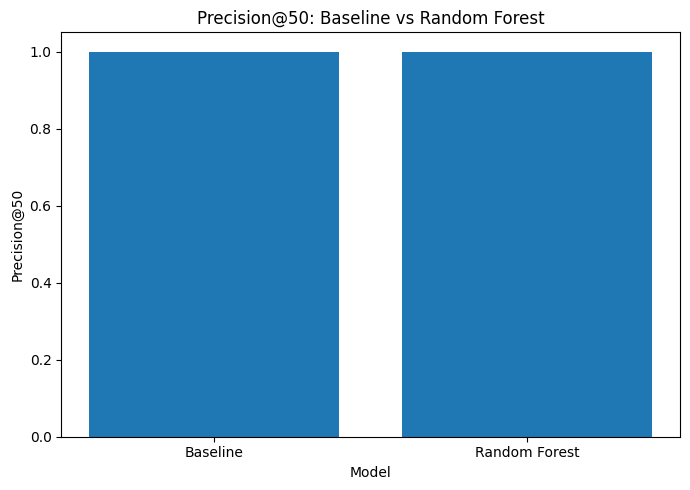

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    comparison["Model"],
    comparison["Precision@50"]
)

plt.ylabel("Precision@50")
plt.xlabel("Model")
plt.title("Precision@50: Baseline vs Random Forest")

plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

In [28]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# Convert probabilities to class predictions
pred_class = (pred_prob >= 0.5).astype(int)

print("Accuracy:", round(
    accuracy_score(y_test, pred_class), 3
))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        pred_class
    )
)

Accuracy: 0.801

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.73      0.78      3014
           1       0.77      0.87      0.82      3149

    accuracy                           0.80      6163
   macro avg       0.81      0.80      0.80      6163
weighted avg       0.81      0.80      0.80      6163



In [29]:
cm = confusion_matrix(
    y_test,
    pred_class
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[2187  827]
 [ 401 2748]]


In [30]:
rf_model = model.named_steps["rf"]

feature_names = model.named_steps[
    "prep"
].get_feature_names_out()

importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

display(importance.head(15))

,feature,importance
18,num__impressions_prev_30d,0.154691
15,num__impressions_last_30d,0.123511
5,num__impressions_90d,0.069351
25,num__avg_position,0.051623
13,num__days_with_impressions,0.049155
21,num__content_age_days,0.040837
17,num__sessions_last_30d,0.028167
3,num__word_count,0.026239
4,num__char_count,0.026006
24,num__ctr,0.025367


## 10. Ranked Action Queue

The model probability is converted into a ranked review queue. Pages with higher decline scores are placed higher in the queue.

Reason codes provide human-readable explanations for why a page may deserve review. These codes are used to support human judgment and are not treated as automatic diagnoses.


In [31]:
queue = test[
    [
        "content_id",
        "content_age_days",
        "days_since_last_update",
        "engagement_rate",
        "ai_traffic_pct",
        "trend_direction",
        "trend_pct"
    ]
].copy()

queue["decline_score"] = pred_prob

queue = queue.sort_values(
    "decline_score",
    ascending=False
).reset_index(drop=True)

queue["priority_rank"] = np.arange(
    1,
    len(queue) + 1
)

print("Queue created:", len(queue))

Queue created: 6163


In [32]:
def reason_code(row):
    reasons = []

    if row["days_since_last_update"] > 180:
        reasons.append("STALE_CONTENT")

    if (
        pd.notna(row["engagement_rate"])
        and row["engagement_rate"] < 0.50
    ):
        reasons.append("LOW_ENGAGEMENT")

    if (
        pd.notna(row["trend_pct"])
        and row["trend_pct"] < 0
    ):
        reasons.append("NEGATIVE_TREND")

    if not reasons:
        reasons.append("MODEL_PRIORITY")

    return "|".join(reasons)


queue["reason_code"] = queue.apply(
    reason_code,
    axis=1
)

print("Reason codes created.")

Reason codes created.


In [33]:
def get_recommended_action(row):
    reason = str(row["reason_code"])

    if (
        "STALE_CONTENT" in reason
        and "NEGATIVE_TREND" in reason
    ):
        return "REFRESH_CONTENT"

    elif (
        "LOW_ENGAGEMENT" in reason
        and "NEGATIVE_TREND" in reason
    ):
        return "REVIEW_INTENT_AND_REFRESH"

    elif "LOW_ENGAGEMENT" in reason:
        return "REVIEW_CONTENT_QUALITY"

    elif "NEGATIVE_TREND" in reason:
        return "INVESTIGATE_DECLINE"

    else:
        return "HUMAN_REVIEW"


queue["recommended_action"] = queue.apply(
    get_recommended_action,
    axis=1
)

print("Recommended actions created.")

Recommended actions created.


In [34]:
display(
    queue[
        [
            "priority_rank",
            "content_id",
            "decline_score",
            "reason_code",
            "recommended_action"
        ]
    ].head(20)
)

,priority_rank,content_id,decline_score,reason_code,recommended_action
0,1,content_29884c0f9255,0.976667,LOW_ENGAGEMENT|NEGATIVE_TREND,REVIEW_INTENT_AND_REFRESH
1,2,content_eb3b2c3bbc34,0.970000,LOW_ENGAGEMENT|NEGATIVE_TREND,REVIEW_INTENT_AND_REFRESH
2,3,content_41538bdb1b1e,0.966667,LOW_ENGAGEMENT|NEGATIVE_TREND,REVIEW_INTENT_AND_REFRESH
3,4,content_9234f5075e7a,0.963333,LOW_ENGAGEMENT|NEGATIVE_TREND,REVIEW_INTENT_AND_REFRESH
4,5,content_9ac61c04930e,0.963333,LOW_ENGAGEMENT|NEGATIVE_TREND,REVIEW_INTENT_AND_REFRESH
5,6,content_f6bf66378677,0.963333,LOW_ENGAGEMENT|NEGATIVE_TREND,REVIEW_INTENT_AND_REFRESH
6,7,content_9e8671965fff,0.956667,LOW_ENGAGEMENT|NEGATIVE_TREND,REVIEW_INTENT_AND_REFRESH
7,8,content_c6bb205d5263,0.956667,LOW_ENGAGEMENT|NEGATIVE_TREND,REVIEW_INTENT_AND_REFRESH
8,9,content_8b08ec7fc725,0.953333,LOW_ENGAGEMENT|NEGATIVE_TREND,REVIEW_INTENT_AND_REFRESH
9,10,content_e5fd30b6e33b,0.950000,LOW_ENGAGEMENT|NEGATIVE_TREND,REVIEW_INTENT_AND_REFRESH


### Human Review Rule

The highest-ranked pages should be reviewed first. Reviewers should inspect freshness, engagement, observed trend signals, search intent, content quality, and business importance before deciding whether to refresh, investigate, monitor, or leave the page unchanged.

The model score is a prioritization signal, not an automatic instruction to change content.


## 11. Exported Results

The ranked action queue is exported as a CSV file so that the prioritization results can be reviewed, reused, and reproduced.


In [35]:
import os

output_dir = "flyrank-ml-internship/work/outputs"

os.makedirs(
    output_dir,
    exist_ok=True
)

queue_path = os.path.join(
    output_dir,
    "ml10_ranked_action_queue.csv"
)

queue.to_csv(
    queue_path,
    index=False
)

print("Ranked queue exported successfully:")
print(queue_path)

Ranked queue exported successfully:
flyrank-ml-internship/work/outputs/ml10_ranked_action_queue.csv


In [36]:
exported_queue = pd.read_csv(queue_path)

print("Exported queue shape:", exported_queue.shape)

required_columns = [
    "content_id",
    "decline_score",
    "reason_code",
    "recommended_action",
    "priority_rank"
]

print("\nRequired columns:")

for col in required_columns:
    print(
        col,
        "->",
        col in exported_queue.columns
    )

Exported queue shape: (6163, 11)

Required columns:
content_id -> True
decline_score -> True
reason_code -> True
recommended_action -> True
priority_rank -> True


In [37]:
print("Top 10 ranked recommendations:")

display(
    exported_queue[
        [
            "priority_rank",
            "content_id",
            "decline_score",
            "reason_code",
            "recommended_action"
        ]
    ].head(10)
)

Top 10 ranked recommendations:


,priority_rank,content_id,decline_score,reason_code,recommended_action
0,1,content_29884c0f9255,0.976667,LOW_ENGAGEMENT|NEGATIVE_TREND,REVIEW_INTENT_AND_REFRESH
1,2,content_eb3b2c3bbc34,0.970000,LOW_ENGAGEMENT|NEGATIVE_TREND,REVIEW_INTENT_AND_REFRESH
2,3,content_41538bdb1b1e,0.966667,LOW_ENGAGEMENT|NEGATIVE_TREND,REVIEW_INTENT_AND_REFRESH
3,4,content_9234f5075e7a,0.963333,LOW_ENGAGEMENT|NEGATIVE_TREND,REVIEW_INTENT_AND_REFRESH
4,5,content_9ac61c04930e,0.963333,LOW_ENGAGEMENT|NEGATIVE_TREND,REVIEW_INTENT_AND_REFRESH
5,6,content_f6bf66378677,0.963333,LOW_ENGAGEMENT|NEGATIVE_TREND,REVIEW_INTENT_AND_REFRESH
6,7,content_9e8671965fff,0.956667,LOW_ENGAGEMENT|NEGATIVE_TREND,REVIEW_INTENT_AND_REFRESH
7,8,content_c6bb205d5263,0.956667,LOW_ENGAGEMENT|NEGATIVE_TREND,REVIEW_INTENT_AND_REFRESH
8,9,content_8b08ec7fc725,0.953333,LOW_ENGAGEMENT|NEGATIVE_TREND,REVIEW_INTENT_AND_REFRESH
9,10,content_e5fd30b6e33b,0.950000,LOW_ENGAGEMENT|NEGATIVE_TREND,REVIEW_INTENT_AND_REFRESH


### Decision-Support Statement

The ranked queue is intended to help content teams prioritize limited review time. A high decline score indicates higher model priority within the evaluated test set, but it does not guarantee that a content change will improve performance.

Final decisions should consider the observed search signals, content quality, freshness, business importance, expected effort, and potential risk. Human review is required before taking action.


## 12. Limitations & Honest Framing

This project is a decision-support workflow rather than a causal or fully predictive system.

### Key Limitations

* The reported model performance is measured only on the held-out client-grouped test set used in this notebook.
* The target label is based on the observed `trend_direction` field, where `"down"` is treated as declining. It does not represent a direct measurement of the cause of decline.
* Precision@50 describes ranking performance for this evaluation split and should not be interpreted as guaranteed performance on future data.
* A high model score indicates higher review priority within the evaluated dataset, but it does not guarantee business value or that changing the page will improve performance.
* Client-grouped validation reduces client-level overlap between training and testing, but it does not guarantee that the model will perform equally well on future clients or future time periods.
* The baseline uses `trend_pct` as a transparent ranking signal. This makes it useful for comparison, but it is not intended to represent a complete production content-prioritization strategy.
* The reason codes in the action queue are heuristic rules based on observed fields. They are human-readable prioritization signals, not formal explanations of the Random Forest's internal predictions.
* The model does not prove Google's ranking algorithm, search-engine behavior, or the causal impact of content updates.
* The available anonymized dataset limits the ability to evaluate business outcomes, individual query behavior, client-specific context, or long-term effects of recommended actions.

### Honest Interpretation

The strongest conclusion from this project is that the available search-performance signals can be used to create a repeatable ranking workflow for human review.

The output should therefore be interpreted as a **prioritized review queue**, not an automatic content decision system. Human reviewers should validate the underlying signals, inspect the content, consider business importance, and decide whether to refresh, investigate, monitor, or leave a page unchanged.


## 13. Monitoring & Retraining Rules

A production version of this workflow should be monitored regularly because search-performance patterns and content behavior can change over time.

### Recommended Monitoring

The following checks should be tracked for each new evaluation period:

1. **Label distribution**
   Monitor the proportion of pages labeled as declining to detect major changes in the target population.

2. **Feature distribution**
   Check whether important input features such as engagement rate, trend signals, content age, and search-performance metrics have shifted.

3. **Ranking performance**
   Recalculate Precision@50 on newly labeled data when ground-truth outcomes become available.

4. **Client coverage**
   Confirm that the workflow continues to evaluate multiple clients and does not become overly dependent on a small number of groups.

5. **Reason-code distribution**
   Monitor whether one reason code becomes disproportionately common, which could indicate changes in the underlying data or heuristic thresholds.

### Retraining Rule

The model should be considered for retraining when:

* ranking performance decreases consistently,
* the distribution of important features changes substantially,
* the declining-label rate changes materially,
* new clients or content types become common,
* or the data-generation process changes.

Retraining should use a new time-based or client-grouped validation period rather than relying only on the original test set.

### Operational Principle

Monitoring should focus on whether the workflow remains useful for prioritizing human review. Model performance should be revalidated before using updated predictions for operational decisions.


## 14. Reproducibility

The analysis is designed to be reproducible from the project repository and notebook.

### Reproducibility Details

* **Repository:** `flyrank-ml-internship`
* **Analysis environment:** Google Colab / Python
* **Primary dataset:** `content_refresh_anonymized.csv`
* **Validation method:** Client-grouped 80/20 train-test split
* **Random state:** `42`
* **Model:** Random Forest Classifier
* **Ranking metric:** Precision@50
* **Output:** Ranked content action queue with priority ranks, reason codes, and recommended actions

The notebook contains the data-loading, preprocessing, validation, modeling, evaluation, ranking, and export steps required to reproduce the analysis.

The exported ranked queue is saved as:

`work/outputs/ml10_ranked_action_queue.csv`

### Reproducibility Principle

All reported results should be generated by running the notebook from top to bottom. Any future changes to the dataset, feature definitions, model configuration, or validation strategy should be documented and evaluated again rather than silently replacing the reported results.


## 15. Acknowledgments & Data Credit

This project was completed as part of the FlyRank ML Internship and uses the anonymized search and content-performance dataset provided for the internship.

**Data credit:** Built on the FlyRank ML Internship dataset.

The analysis follows the public-safe requirements of the dataset. No client names, domains, private search queries, credentials, or other sensitive information are included in the research output.

The results presented in this project are the author's analysis of the provided anonymized data and should not be interpreted as official conclusions from FlyRank.


## Abstract

This project investigates whether safe search-performance signals can be used to rank content pages that deserve review for decline, recovery, or improvement. A client-grouped machine-learning workflow was developed using anonymized content and search-performance data, with a Random Forest classifier evaluated against a transparent trend-based baseline. The primary evaluation metric is Precision@50, which measures how effectively the workflow prioritizes declining pages among the 50 highest-ranked records. The resulting ranked action queue combines model scores with human-readable reason codes and recommended actions to support efficient content review. The results should be interpreted as directional decision-support evidence rather than causal proof of search-engine behavior or a guarantee that recommended content changes will improve performance.


In [38]:
# Final Results Summary

print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)

print("\nDataset")
print("Total rows:", len(df))
print("Total features used:", len(features))
print("Training rows:", len(train))
print("Testing rows:", len(test))

print("\nValidation")
print("Training clients:", train["client_id"].nunique())
print("Testing clients:", test["client_id"].nunique())
print("Client overlap:", len(set(train["client_id"]) & set(test["client_id"])))

print("\nRanking Performance")
print("Baseline Precision@50:", round(baseline_p50, 3))
print("Random Forest Precision@50:", round(model_p50, 3))
print("Absolute improvement:", round(improvement, 3))

print("\nClassification Performance")
print("Accuracy:", round(accuracy_score(y_test, pred_class), 3))

print("\nTop Feature Signals")
display(importance.head(10))

print("\nFinal Interpretation")

if model_p50 > baseline_p50:
    print(
        "The Random Forest produced higher Precision@50 than the "
        "trend-based baseline on the held-out test set."
    )
elif model_p50 < baseline_p50:
    print(
        "The trend-based baseline produced higher Precision@50 than "
        "the Random Forest on the held-out test set."
    )
else:
    print(
        "The Random Forest and baseline produced the same Precision@50 "
        "on the held-out test set."
    )

FINAL RESULTS SUMMARY

Dataset
Total rows: 30000
Total features used: 40
Training rows: 23837
Testing rows: 6163

Validation
Training clients: 25
Testing clients: 7
Client overlap: 0

Ranking Performance
Baseline Precision@50: 1.0
Random Forest Precision@50: 1.0
Absolute improvement: 0.0

Classification Performance
Accuracy: 0.801

Top Feature Signals


,feature,importance
18,num__impressions_prev_30d,0.154691
15,num__impressions_last_30d,0.123511
5,num__impressions_90d,0.069351
25,num__avg_position,0.051623
13,num__days_with_impressions,0.049155
21,num__content_age_days,0.040837
17,num__sessions_last_30d,0.028167
3,num__word_count,0.026239
4,num__char_count,0.026006
24,num__ctr,0.025367



Final Interpretation
The Random Forest and baseline produced the same Precision@50 on the held-out test set.


In [39]:
monitoring_df = pd.DataFrame({
    "metric": [
        "Test rows",
        "Decline rate",
        "Precision@50",
        "Test clients"
    ],
    "value": [
        len(test),
        round(y_test.mean(), 3),
        round(model_p50, 3),
        test["client_id"].nunique()
    ]
})

display(monitoring_df)

,metric,value
0,Test rows,6163.000
1,Decline rate,0.511
2,Precision@50,1.000
3,Test clients,7.000


In [40]:
monitoring_rules = pd.DataFrame({
    "trigger": [
        "Precision@50 decreases materially",
        "Decline rate changes substantially",
        "Important feature distributions shift",
        "Important fields become missing",
        "Data definitions or collection process change",
        "New labeled data becomes available"
    ],
    "response": [
        "Review model ranking quality",
        "Investigate whether the content environment changed",
        "Check for data drift and reassess model validity",
        "Investigate the data pipeline before using recommendations",
        "Revalidate the model and feature definitions",
        "Consider retraining and revalidation"
    ]
})

display(monitoring_rules)

,trigger,response
0,Precision@50 decreases materially,Review model ranking quality
1,Decline rate changes substantially,Investigate whether the content environment ch...
2,Important feature distributions shift,Check for data drift and reassess model validity
3,Important fields become missing,Investigate the data pipeline before using rec...
4,Data definitions or collection process change,Revalidate the model and feature definitions
5,New labeled data becomes available,Consider retraining and revalidation


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.